In [152]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [374]:
def report_stat(series, metric="mean"):
    if metric == 'median':
        metric = '50%'
    df = series.dropna().describe()[["count", metric, "std"]]
    df["lower_ci"] = df[metric] - 1.96*(df["std"]/np.sqrt(df["count"]))
    df["upper_ci"] = df[metric] + 1.96*(df["std"]/np.sqrt(df["count"]))
    print(f'{df[metric]:.6f} [{df["lower_ci"]:.6f}, {df["upper_ci"]:.6f}] (n = {df["count"]})')

In [375]:
!ls

a_fop_tmm.csv
a_fop.csv
a_intergenic.windowed.pi
Afusca Svir ortholog pop gen.ipynb
all_chrs.intergenic.pi.tsv
allacma_fusca.cds-nt-longest.fa
allacma_fusca.cds-nt.fa
allacma_fusca.cds.bed
allacma_fusca.gc.bed
allacma_fusca.gene.AGAT.bed
allacma_fusca.genomefile
allacma_fusca.longest_isoform.gff3
allacma_fusca.longest_isoforms.0D.bed
allacma_fusca.longest_isoforms.4D.bed
allacma_fusca.longest_isoforms.pi.tsv
allacma_fusca.pdf
allacma_fusca.sfs.chrom.tsv
allacma_fusca.sfs.total.tsv
allacma_fusca.sminthurus_viridis.orthodiver_agg.tsv
allacma_fusca.sp1.SCO_genes.txt
allacma_fusca.vs.sminthurus_viridis
degenotate
dnds.ipynb
dnds.png
dnds.svg
Fop.png
Fop.svg
inputs
Orthogroups_SingleCopyOrthologues.txt
Orthogroups.tsv
pi_dnds.png
pi_dnds.svg
pi.png
pi.svg
SC_orthogroups.txt
SFS.ipynb
sminthurus_viridis.cds.bed
sminthurus_viridis.longest_isoform.gff3
sminthurus_viridis.sp2.SCO_genes.txt
summarise dfe alpha bootstrap.ipynb
x_fop_tmm.csv
x_fop.csv
x_intergenic.windowed.pi


In [376]:
gene_bed = pd.read_csv('allacma_fusca.gene.AGAT.bed', sep='\t', header=None)
SCOs = pd.read_csv('allacma_fusca.sp1.SCO_genes.txt', sep='\t', header=None)
sc_orthogroups = pd.read_csv('Orthogroups_SingleCopyOrthologues.txt', sep='\t', header=None)
Orthogroups = pd.read_csv('Orthogroups.tsv', sep='\t')
Orthogroups = Orthogroups[Orthogroups['Orthogroup'].isin(sc_orthogroups[0])]
Orthogroups['gene'] = Orthogroups['allacma_fusca.best.pep'].str.split('.', expand=True)[[1,2]].agg('.'.join, axis=1)

In [377]:
Orthogroups

,Orthogroup,allacma_fusca.best.pep,sminthurus_viridis.best.pep,gene
5214,OG0005214,allacma_fusca.g157.t3,sminthurus_viridis.g25163.t1,g157.t3
5215,OG0005215,allacma_fusca.g159.t1,sminthurus_viridis.g41897.t1,g159.t1
5217,OG0005217,allacma_fusca.g171.t1,sminthurus_viridis.g25177.t1,g171.t1
5218,OG0005218,allacma_fusca.g172.t1,sminthurus_viridis.g25178.t1,g172.t1
5221,OG0005221,allacma_fusca.g236.t1,sminthurus_viridis.g25194.t1,g236.t1
...,...,...,...,...
17756,OG0017756,allacma_fusca.g77.t1,sminthurus_viridis.g40716.t2,g77.t1
17759,OG0017759,allacma_fusca.g99.t1,sminthurus_viridis.g15801.t1,g99.t1
17760,OG0017760,allacma_fusca.g100.t1,sminthurus_viridis.g17182.t1,g100.t1
17761,OG0017761,allacma_fusca.g116.t1,sminthurus_viridis.g12322.t1,g116.t1


In [378]:
Orthogroups = Orthogroups.reset_index()[['Orthogroup', 'gene']]
Orthogroups['gene']  = Orthogroups['gene'].astype(str)
gene_loc = gene_bed[gene_bed[3].isin(SCOs[0])][[0,3]].rename(columns={0:'chrom',3:'gene'})
gene_loc['gene'] = gene_loc['gene'].astype(str)

In [379]:
locs = Orthogroups.merge(gene_loc, how='outer', on='gene')
locs['pi_gene'] = locs['gene'].str.split('.', expand=True)[0]
locs

,Orthogroup,gene,chrom,pi_gene
0,OG0005214,g157.t3,OX359245.1,g157
1,OG0005215,g159.t1,OX359245.1,g159
2,OG0005217,g171.t1,OX359245.1,g171
3,OG0005218,g172.t1,OX359245.1,g172
4,OG0005221,g236.t1,OX359245.1,g236
...,...,...,...,...
12291,OG0017756,g77.t1,CAMXBY010000047.1,g77
12292,OG0017759,g99.t1,CAMXBY010000060.1,g99
12293,OG0017760,g100.t1,CAMXBY010000060.1,g100
12294,OG0017761,g116.t1,CAMXBY010000065.1,g116


In [380]:
x_list = ['OX359249.1', 'OX359250.1']

In [381]:
pi_df = pd.read_csv('allacma_fusca.longest_isoforms.pi.tsv', sep='\t')
print(f"total: {pi_df.shape[0]} genes")
print(f"A total: {pi_df[~pi_df['chrom'].isin(x_list)].shape[0]} genes")
print(f"X total: {pi_df[pi_df['chrom'].isin(x_list)].shape[0]} genes")
print(f"A 0D 0count: {pi_df[(pi_df['0D_pi'].isna()) & ~(pi_df['chrom'].isin(x_list))].shape[0]} genes")
print(f"A 4D 0count: {pi_df[(pi_df['4D_pi'].isna()) & ~(pi_df['chrom'].isin(x_list))].shape[0]} genes")
print(f"X 0D 0count: {pi_df[(pi_df['0D_pi'].isna()) & (pi_df['chrom'].isin(x_list))].shape[0]} genes")
print(f"X 4D 0count: {pi_df[(pi_df['4D_pi'].isna()) & (pi_df['chrom'].isin(x_list))].shape[0]} genes")
#pi_df = pi_df.fillna(0)

# NaN is keyerror from allel sequence diversity
pi_df = pi_df.dropna()
#pi_df = pi_df.dropna(subset=['4D_pi'])
#pi_df['pi_gene'] = pi_df['feature'].str.split('=', expand=True)[1]
#pi_sco = pi_df.merge(locs[['Orthogroup','pi_gene']], how = 'outer', on = 'pi_gene')
#pi_sco = pi_sco.dropna()

total: 24243 genes
A total: 18542 genes
X total: 5701 genes
A 0D 0count: 6910 genes
A 4D 0count: 6718 genes
X 0D 0count: 4183 genes
X 4D 0count: 4223 genes


In [382]:
print(f'{100*6910/18542}% of A linked genes have 0 0D pi')
print(f'{100*6918/18542}% of A linked genes have 0 4D pi')
print(f'{100*4183/5701}% of X linked genes have 0 0D pi')
print(f'{100*4223/5701}% of X linked genes have 0 4D pi')

37.266745766368246% of A linked genes have 0 0D pi
37.309891058138284% of A linked genes have 0 4D pi
73.37309243992281% of X linked genes have 0 0D pi
74.07472373267848% of X linked genes have 0 4D pi


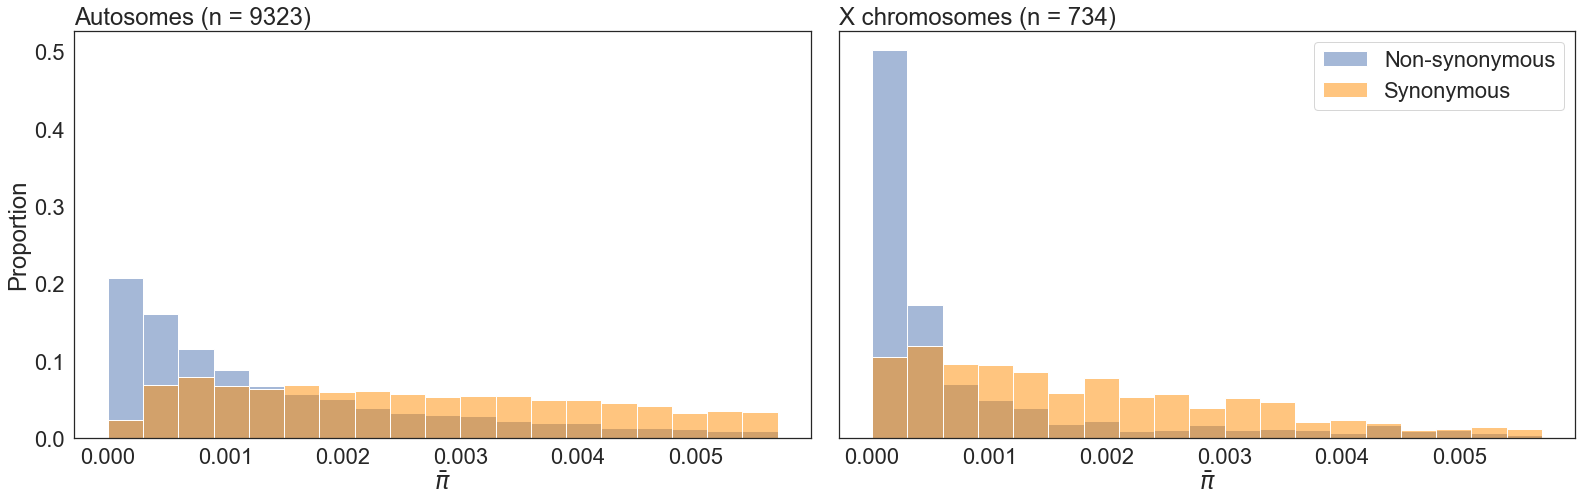

In [383]:
## Looks weird, can I use orthodiver values?? Why has this changed from previous plots?
## I think dropping NA is removing 0D sites with no diversity so dont want to remove this
## Set 0D_pi to 0 is 4D is not NA
## Subsample necessary comparisons
## Density scale looks wrong?

sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = [22.5,7.5], sharey=True)

A_ax = axs[0]
X_ax = axs[1]

minx = 0.000001
maxx = 0.006
step = 20
bins = np.arange(minx, maxx, (maxx-minx)/step)

sns.histplot(pi_df[~pi_df['chrom'].isin(x_list)]['0D_pi'], bins=bins, alpha = 0.5, label='OD', stat='proportion', ax = A_ax)
sns.histplot(pi_df[~pi_df['chrom'].isin(x_list)]['4D_pi'], bins=bins, alpha = 0.5, label='4D', stat='proportion', ax = A_ax, color='darkorange')
sns.histplot(pi_df[pi_df['chrom'].isin(x_list)]['0D_pi'], bins=bins, alpha = 0.5, label='Non-synonymous', stat='proportion', ax = X_ax)
sns.histplot(pi_df[pi_df['chrom'].isin(x_list)]['4D_pi'], bins=bins, alpha = 0.5, label='Synonymous', stat='proportion', ax = X_ax, color='darkorange')

X_ax.legend(loc='upper right')
A_ax.set_title(f"Autosomes (n = {pi_df[~pi_df['chrom'].isin(x_list)].shape[0]})", loc='left')
X_ax.set_title(f"X chromosomes (n = {pi_df[pi_df['chrom'].isin(x_list)].shape[0]})", loc='left')
A_ax.set_xlabel(r'$\bar\pi$')
X_ax.set_xlabel(r'$\bar\pi$')

plt.tight_layout()

#plt.savefig("pi.svg")
#plt.savefig("pi.png")

In [385]:
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['4D_pi'])
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['4D_pi'])

0.002112 [0.001764, 0.002460] (n = 734.0)
0.005550 [0.004595, 0.006505] (n = 734.0)
0.002990 [0.002890, 0.003090] (n = 9323.0)
0.009727 [0.009481, 0.009974] (n = 9323.0)


In [384]:
# SCOs
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['4D_pi'])
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['4D_pi'])

0.002112 [0.001764, 0.002460] (n = 734.0)
0.005550 [0.004595, 0.006505] (n = 734.0)
0.002990 [0.002890, 0.003090] (n = 9323.0)
0.009727 [0.009481, 0.009974] (n = 9323.0)


In [355]:
# fillna0
#0d ratios
print(0.000349/0.001674)
#4d_ratios
print(0.000978/0.005557)
#x_ratios
print(0.000349/0.000978)
#a_ratios
print(0.001674/0.005557)

0.20848267622461172
0.1759942414972107
0.3568507157464213
0.30124167716393735


In [394]:
dxy_df = pd.read_csv('allacma_fusca.sminthurus_viridis.orthodiver_agg.tsv', sep='\t')
dxy_df = dxy_df.merge(locs, how = 'outer',on = 'Orthogroup')
dxy_df = dxy_df.dropna()
len(dxy_df['Orthogroup'].unique())

12247

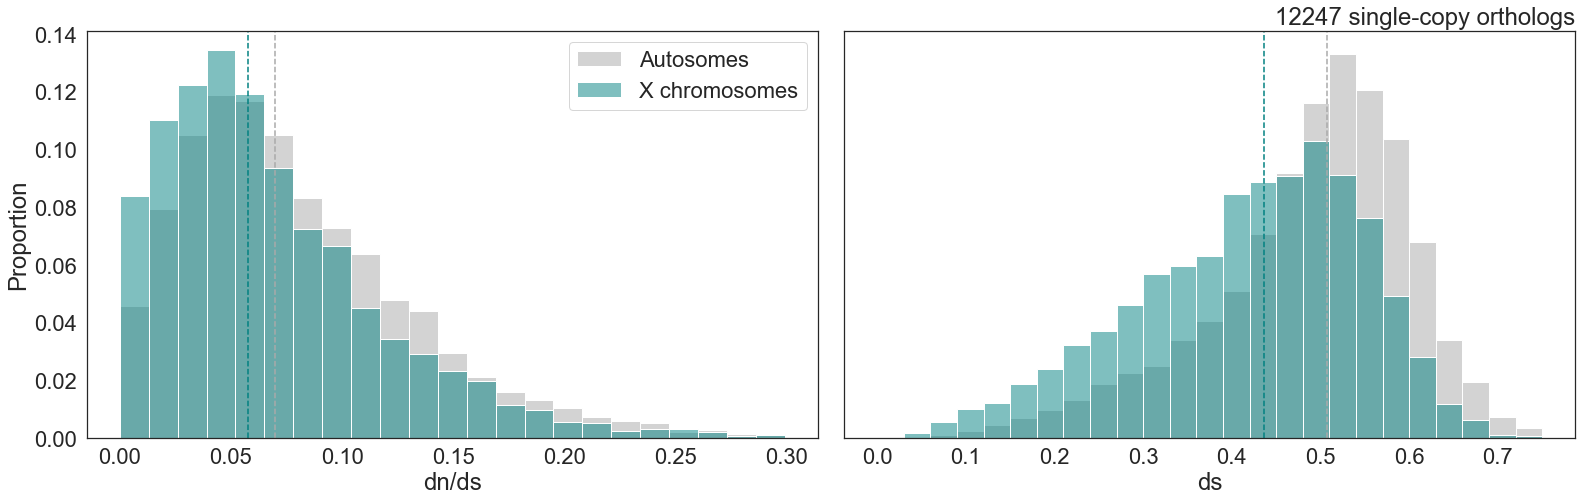

In [395]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(ncols = 2, figsize = [22.5,7.5], sharey=True)

dnds = axs[0]
ds = axs[1]

dnds_bins = np.arange(0, 0.31, 0.013)
ds_bins = np.arange(0, 0.76, 0.03)

sns.histplot(dxy_df[~dxy_df['chrom'].isin(x_list)]['dnds'], label='Autosomes', bins=dnds_bins, alpha = 0.5, stat='proportion', ax = dnds, color='darkgrey')
sns.histplot(dxy_df[dxy_df['chrom'].isin(x_list)]['dnds'], label='X chromosomes', bins=dnds_bins, alpha = 0.5, stat='proportion', ax = dnds, color='teal')

sns.histplot(dxy_df[~dxy_df['chrom'].isin(x_list)]['4d_dxy'], bins=ds_bins, alpha = 0.5, stat='proportion', ax = ds, color='darkgrey')
sns.histplot(dxy_df[dxy_df['chrom'].isin(x_list)]['4d_dxy'], bins=ds_bins, alpha = 0.5, stat='proportion', ax = ds, color='teal')

dnds.legend()

dnds.set_xlabel('dn/ds')
ds.set_xlabel('ds')

ds.set_title(f"{dxy_df.dropna().shape[0]} single-copy orthologs", loc='right')


ds.axvline(dxy_df[dxy_df['chrom'].isin(x_list)]['4d_dxy'].median(), linestyle='--',color='teal')
ds.axvline(dxy_df[~dxy_df['chrom'].isin(x_list)]['4d_dxy'].median(), linestyle='--',color='darkgrey')

dnds.axvline(dxy_df[dxy_df['chrom'].isin(x_list)]['dnds'].median(), linestyle='--',color='teal')
dnds.axvline(dxy_df[~dxy_df['chrom'].isin(x_list)]['dnds'].median(), linestyle='--',color='darkgrey')


plt.tight_layout()

plt.savefig("dnds.svg")
plt.savefig("dnds.png")

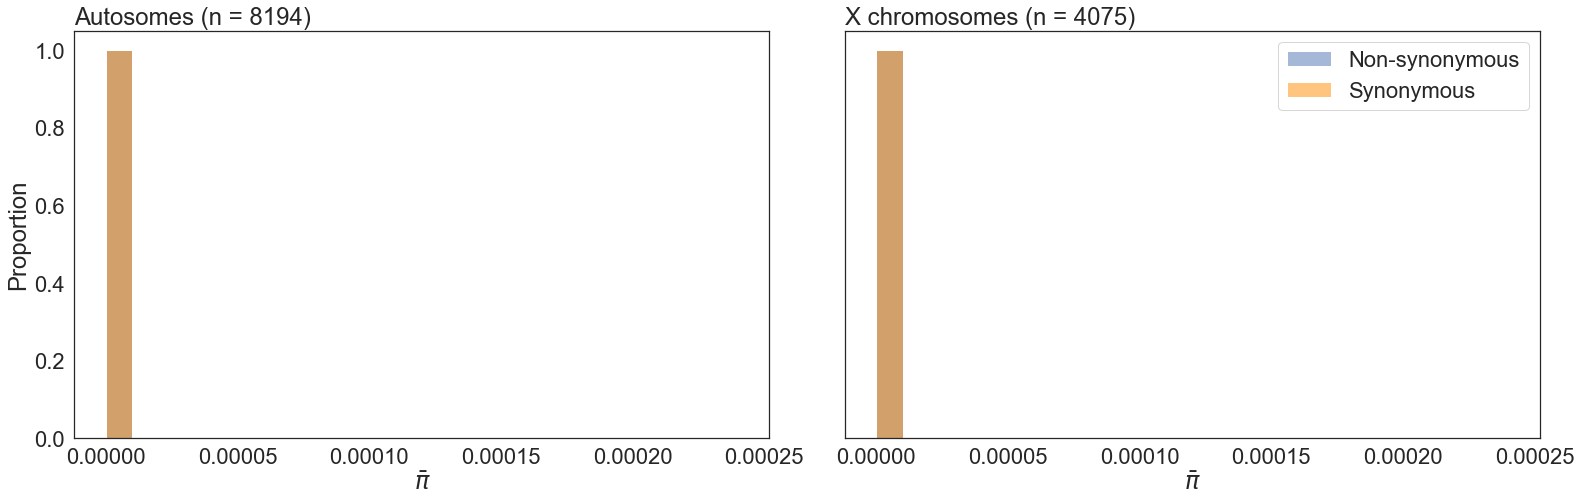

In [390]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = [22.5,7.5], sharey=True)

A_ax = axs[0]
X_ax = axs[1]

minx = 0.0
maxx = 0.00025
step = 25
bins = np.arange(minx, maxx, (maxx-minx)/step)

sns.histplot(dxy_df[(~dxy_df['chrom'].isin(x_list)) ]['0d_pi_allacma_fusca'], bins=bins, alpha = 0.5, label='OD', stat='proportion', ax = A_ax)
sns.histplot(dxy_df[(~dxy_df['chrom'].isin(x_list)) ]['4d_pi_allacma_fusca'], bins=bins, alpha = 0.5, label='4D', stat='proportion', ax = A_ax, color='darkorange')
sns.histplot(dxy_df[(dxy_df['chrom'].isin(x_list)) ]['0d_pi_allacma_fusca'], bins=bins, alpha = 0.5, label='Non-synonymous', stat='proportion', ax = X_ax)
sns.histplot(dxy_df[(dxy_df['chrom'].isin(x_list)) ]['4d_pi_allacma_fusca'], bins=bins, alpha = 0.5, label='Synonymous', stat='proportion', ax = X_ax, color='darkorange')

X_ax.legend(loc='upper right')
A_ax.set_title(f"Autosomes (n = {dxy_df[~dxy_df['chrom'].isin(x_list)].dropna().shape[0]})", loc='left')
X_ax.set_title(f"X chromosomes (n = {dxy_df[dxy_df['chrom'].isin(x_list)].dropna().shape[0]})", loc='left')
A_ax.set_xlabel(r'$\bar\pi$')
X_ax.set_xlabel(r'$\bar\pi$')

plt.tight_layout()

In [391]:
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) ]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) ]['4d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) ]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) ]['4d_pi_allacma_fusca'])

0.000267 [0.000238, 0.000295] (n = 8194.0)
0.002866 [0.002672, 0.003061] (n = 8194.0)
0.000043 [0.000029, 0.000056] (n = 4075.0)
0.000487 [0.000283, 0.000691] (n = 4075.0)


In [347]:
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[~pi_df['chrom'].isin(x_list)]['4D_pi'])
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['0D_pi'])
report_stat(pi_df[pi_df['chrom'].isin(x_list)]['4D_pi'])

0.001674 [0.001619, 0.001730] (n = 18542.0)
0.005557 [0.005414, 0.005701] (n = 18542.0)
0.000349 [0.000299, 0.000400] (n = 5701.0)
0.000978 [0.000843, 0.001113] (n = 5701.0)


In [172]:
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0) ]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])

0.000780 [0.000679, 0.000881] (n = 1592.0)
0.014754 [0.013995, 0.015513] (n = 1592.0)
0.000554 [0.000317, 0.000791] (n = 171.0)
0.011602 [0.007029, 0.016175] (n = 171.0)


In [168]:
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0)]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0) ]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])

0.002717 [0.002491, 0.002943] (n = 804.0)
0.014754 [0.013995, 0.015513] (n = 1592.0)
0.002147 [0.001646, 0.002648] (n = 81.0)
0.011602 [0.007029, 0.016175] (n = 171.0)


In [169]:
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(~dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['0d_pi_allacma_fusca'])
report_stat(dxy_df[(dxy_df['chrom'].isin(x_list)) & (dxy_df['0d_pi_allacma_fusca'] > 0) & (dxy_df['4d_pi_allacma_fusca'] > 0)]['4d_pi_allacma_fusca'])

0.002759 [0.002475, 0.003043] (n = 450.0)
0.018399 [0.016601, 0.020198] (n = 450.0)
0.002872 [0.002008, 0.003736] (n = 33.0)
0.029219 [0.006801, 0.051638] (n = 33.0)


In [397]:
report_stat(dxy_df[dxy_df['chrom'].isin(x_list)]['0d_dxy'])
report_stat(dxy_df[dxy_df['chrom'].isin(x_list)]['4d_dxy'])
report_stat(dxy_df[dxy_df['chrom'].isin(x_list)]['dnds'])

report_stat(dxy_df[~dxy_df['chrom'].isin(x_list)]['0d_dxy'])
report_stat(dxy_df[~dxy_df['chrom'].isin(x_list)]['4d_dxy'])
report_stat(dxy_df[~dxy_df['chrom'].isin(x_list)]['dnds'])

0.029251 [0.028527, 0.029975] (n = 4075.0)
0.419301 [0.415364, 0.423238] (n = 4075.0)
0.069185 [0.067537, 0.070834] (n = 4075.0)
0.039753 [0.039153, 0.040353] (n = 8172.0)
0.487382 [0.484882, 0.489883] (n = 8172.0)
0.081972 [0.080700, 0.083244] (n = 8172.0)


In [398]:
dxy_df['alpha'].describe()

count    12247.000000
mean         0.420741
std         16.352249
min      -1788.234646
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: alpha, dtype: float64

In [401]:
dxy_df[dxy_df['chrom'].isin(x_list)]['alpha'].describe()

count    4075.000000
mean        0.868744
std         1.474231
min       -55.490371
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: alpha, dtype: float64

In [404]:
dxy_df[~dxy_df['chrom'].isin(x_list)]['alpha'].quantile(0.025)

-4.244235826087801

In [405]:
dxy_df[~dxy_df['chrom'].isin(x_list)]['alpha'].quantile(0.975)

1.0

In [400]:
dxy_df[~dxy_df['chrom'].isin(x_list)]['alpha'].describe()

count    8172.000000
mean        0.197342
std        19.987917
min     -1788.234646
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: alpha, dtype: float64

In [30]:
#Autosomes
#[0-1) = 0.53646 [0.53574, 0.53719]
#[1-10) = 0.09365 [0.09203, 0.09527]
#[10-100) = 0.10969 [0.10755, 0.11183]
#>=100 = 0.26020 [0.25716, 0.26323]
#X
#[0-1) = 0.18173 [0.18051, 0.18296]
#[1-10) = 0.13788 [0.13587, 0.13990]
#[10-100) = 0.23676 [0.23167, 0.24185]
#>=100 = 0.44362 [0.43775, 0.44950]

Text(0, 0.5, 'Proportion')

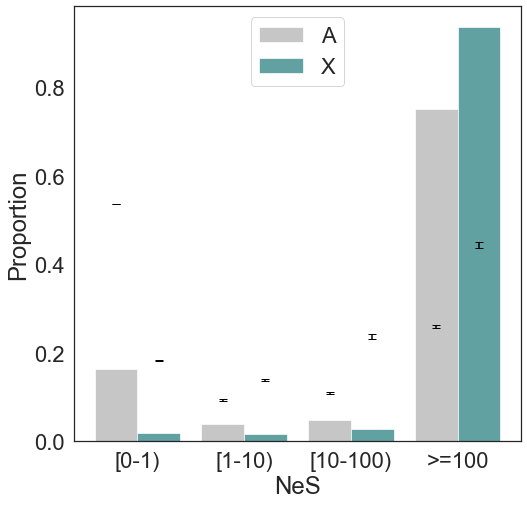

In [373]:
# all

cats = ['[0-1)', '[1-10)', '[10-100)', '>=100','[0-1)', '[1-10)', '[10-100)', '>=100']
vals = [0.163329,0.038491,0.047561,0.750618,0.019230,0.015771,0.028704,0.93629]
linkage = ['A','A','A','A','X','X','X','X']
ci_lower = [0.53574,0.09203,0.10755,0.25716,0.18051,0.13587,0.23167,0.43775]
ci_upper = [0.53719,0.09527,0.11183,0.26323,0.18296,0.13990,0.24185,0.44950]
y_lower = np.array([x - y for x,y in zip(vals, ci_lower)])
y_upper = np.array([y - x for x,y in zip(vals, ci_upper)])

dfe_df = pd.DataFrame({'cats':cats, 'linkage':linkage, 'prop':vals, 'y_lower':y_lower,'y_upper':y_upper})

plt.figure(figsize=(8, 8))
ax = sns.barplot(x='cats', y='prop', hue='linkage', palette = ['darkgrey','teal'], data=dfe_df, alpha = 0.66)

errors = [y_lower, y_upper]
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]
ax.errorbar(x_coords, y_coords, yerr=errors, fmt='none', ecolor = 'black', capsize=4)

#ax.spines[['top', 'right']].set_visible(False)
#sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

ax.legend(title=None, loc='upper center')
ax.set_xlabel('NeS')
ax.set_ylabel('Proportion')

In [407]:
#PGE
def a_to_x_sub_ratio_pge(h):
    return (3*h)/(1+(2*h))

def get_h_pge(rax):
    return rax/(3-2*rax)
    

mckr_rax  = 0.1973/0.869
dfe_alpha_rax  = 0.1973/0.634

h = np.linspace(0,1, 1000)

In [ ]:
Autosomes
[0-1) = 0.16333 [0.16302, 0.16364]
[1-10) = 0.03849 [0.03784, 0.03915]
[10-100) = 0.04756 [0.04657, 0.04855]
>=100 = 0.75062 [0.74929, 0.75195]
X
[0-1) = 0.01923 [0.01879, 0.01967]
[1-10) = 0.01577 [0.01518, 0.01637]
[10-100) = 0.02870 [0.02675, 0.03065]
>=100 = 0.93630 [0.93419, 0.93840]

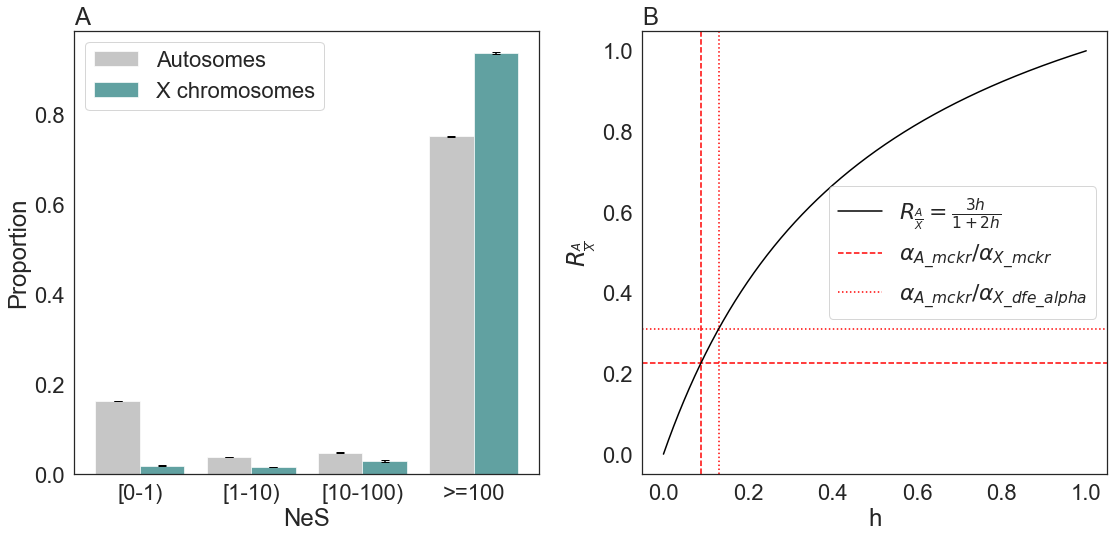

In [434]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(ncols = 2, figsize=(16, 8), tight_layout=True)

dfe_ax = axs[0]
h_ax = axs[1]

#####

cats = ['[0-1)', '[1-10)', '[10-100)', '>=100','[0-1)', '[1-10)', '[10-100)', '>=100']
vals = [0.163329,0.038491,0.047561,0.750618,0.019230,0.015771,0.028704,0.93629]
linkage = ['Autosomes','Autosomes','Autosomes','Autosomes','X chromosomes','X chromosomes','X chromosomes','X chromosomes']
ci_lower = [0.16302,0.03784,0.04657,0.74929,0.01879,0.01518,0.02675,0.93419]
ci_upper = [0.16364,0.03915,0.04855, 0.75195,0.01967,0.01637,0.03065,0.93840]
y_lower = np.array([x - y for x,y in zip(vals, ci_lower)])
y_upper = np.array([y - x for x,y in zip(vals, ci_upper)])

dfe_df = pd.DataFrame({'cats':cats, 'linkage':linkage, 'prop':vals, 'y_lower':y_lower,'y_upper':y_upper})
dfe_ax = sns.barplot(x='cats', y='prop', hue='linkage', palette = ['darkgrey','teal'], data=dfe_df, alpha = 0.66, 
                    ax=dfe_ax)

errors = [y_lower, y_upper]
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]
dfe_ax.errorbar(x_coords, y_coords, yerr=errors, fmt='none', ecolor = 'black', capsize=4)

dfe_ax.legend(title=None, loc='upper left')
dfe_ax.set_xlabel('NeS')
dfe_ax.set_ylabel('Proportion')

#####

RX = a_to_x_sub_ratio_pge(h)
h_ax = sns.lineplot(x=h,
            y=RX,
            color='black',
            label=r'$R_\frac{A}{X} = \frac{3h}{1+2h}$',
            ax=h_ax)
#h_ax = sns.lineplot(x=h,
#            y=h,
#            label='male limited',
#            ax=h_ax)
#h_ax.axhline(y=1, color='red', label = 'female limited')
h_ax.set_xlabel('h')
h_ax.set_ylabel(r'$R_\frac{A}{X}$')

mckr_label = '$α_{A\_mckr}/α_{X\_mckr} $'
dfe_alpha_label = '$α_{A\_mckr}/α_{X\_dfe\_alpha}$'

h_ax.axhline(mckr_rax, linestyle='--', zorder=0, color='red', label = mckr_label)
h_ax.axvline(get_h_pge(mckr_rax), linestyle='--', zorder=0, color='red')
h_ax.axhline(dfe_alpha_rax, linestyle=':', zorder=0, color='red', label = dfe_alpha_label)
h_ax.axvline(get_h_pge(dfe_alpha_rax), linestyle=':', zorder=0, color='red')
h_ax.legend(loc='right')
#plt.title('PGE')

dfe_ax.set_title('A', loc='left')
h_ax.set_title('B', loc='left')

plt.savefig("dfe_h.svg")
plt.savefig("dfe_h.png")

Text(0, 0.5, 'Proportion')

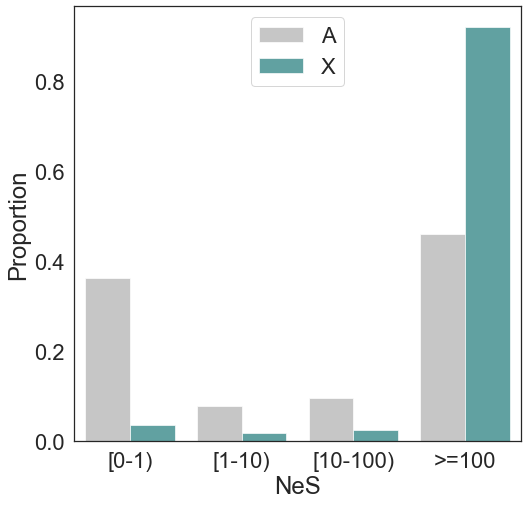

In [32]:
# male biased onwards with demography from all, not sure if that matters

cats = ['[0-1)', '[1-10)', '[10-100)', '>=100','[0-1)', '[1-10)', '[10-100)', '>=100']
vals = [0.363418,0.079278,0.096556,0.460748, 0.035469,0.017443,0.026020,0.921068]
linkage = ['A','A','A','A','X','X','X','X']
#ci_lower = [0.53574,0.09203,0.10755,0.25716,0.18051,0.13587,0.23167,0.43775]
#ci_upper = [0.53719,0.09527,0.11183,0.26323,0.18296,0.13990,0.24185,0.44950]
#y_lower = np.array([x - y for x,y in zip(vals, ci_lower)])
#y_upper = np.array([y - x for x,y in zip(vals, ci_upper)])

dfe_df = pd.DataFrame({'cats':cats, 'linkage':linkage, 'prop':vals, 'y_lower':y_lower,'y_upper':y_upper})

plt.figure(figsize=(8, 8))
ax = sns.barplot(x='cats', y='prop', hue='linkage', palette = ['darkgrey','teal'], data=dfe_df, alpha = 0.66)

#errors = [y_lower, y_upper]
#x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
#y_coords = [p.get_height() for p in ax.patches]
#ax.errorbar(x_coords, y_coords, yerr=errors, fmt='none', ecolor = 'black', capsize=4)

#ax.spines[['top', 'right']].set_visible(False)
#sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

ax.legend(title=None, loc='upper center')
ax.set_xlabel('NeS')
ax.set_ylabel('Proportion')

Text(0, 0.5, 'Proportion')

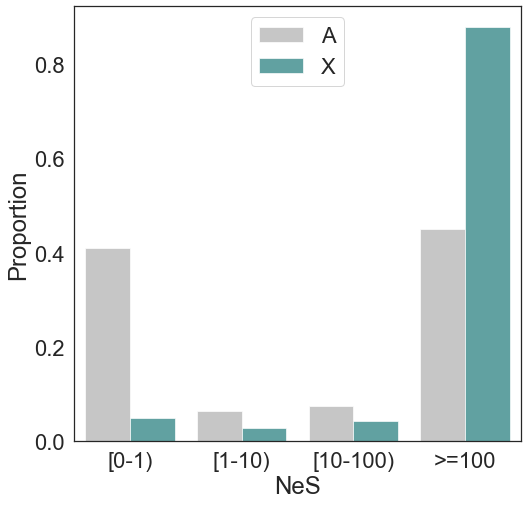

In [33]:
# female biased

cats = ['[0-1)', '[1-10)', '[10-100)', '>=100','[0-1)', '[1-10)', '[10-100)', '>=100']
vals = [0.410190,0.064363,0.074461,0.450986, 0.049120,0.027998,0.043957,0.878924]
linkage = ['A','A','A','A','X','X','X','X']
#ci_lower = [0.53574,0.09203,0.10755,0.25716,0.18051,0.13587,0.23167,0.43775]
#ci_upper = [0.53719,0.09527,0.11183,0.26323,0.18296,0.13990,0.24185,0.44950]
#y_lower = np.array([x - y for x,y in zip(vals, ci_lower)])
#y_upper = np.array([y - x for x,y in zip(vals, ci_upper)])

dfe_df = pd.DataFrame({'cats':cats, 'linkage':linkage, 'prop':vals, 'y_lower':y_lower,'y_upper':y_upper})

plt.figure(figsize=(8, 8))
ax = sns.barplot(x='cats', y='prop', hue='linkage', palette = ['darkgrey','teal'], data=dfe_df, alpha = 0.66)

#errors = [y_lower, y_upper]
#x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
#y_coords = [p.get_height() for p in ax.patches]
#ax.errorbar(x_coords, y_coords, yerr=errors, fmt='none', ecolor = 'black', capsize=4)

#ax.spines[['top', 'right']].set_visible(False)
#sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

ax.legend(title=None, loc='upper center')
ax.set_xlabel('NeS')
ax.set_ylabel('Proportion')

Text(0, 0.5, 'Proportion')

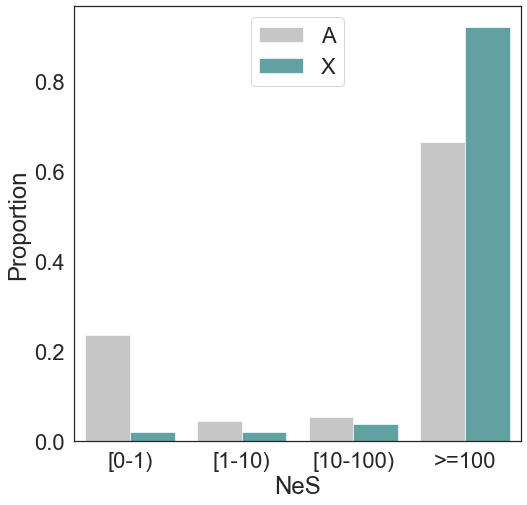

In [34]:
# unbiased
cats = ['[0-1)', '[1-10)', '[10-100)', '>=100','[0-1)', '[1-10)', '[10-100)', '>=100']
vals = [0.235321,0.045262,0.053967,0.665450,0.021639,0.019985,0.038440,0.919936]
linkage = ['A','A','A','A','X','X','X','X']
#ci_lower = [0.53574,0.09203,0.10755,0.25716,0.18051,0.13587,0.23167,0.43775]
#ci_upper = [0.53719,0.09527,0.11183,0.26323,0.18296,0.13990,0.24185,0.44950]
#y_lower = np.array([x - y for x,y in zip(vals, ci_lower)])
#y_upper = np.array([y - x for x,y in zip(vals, ci_upper)])

dfe_df = pd.DataFrame({'cats':cats, 'linkage':linkage, 'prop':vals, 'y_lower':y_lower,'y_upper':y_upper})

plt.figure(figsize=(8, 8))
ax = sns.barplot(x='cats', y='prop', hue='linkage', palette = ['darkgrey','teal'], data=dfe_df, alpha = 0.66)

#errors = [y_lower, y_upper]
#x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
#y_coords = [p.get_height() for p in ax.patches]
#ax.errorbar(x_coords, y_coords, yerr=errors, fmt='none', ecolor = 'black', capsize=4)

#ax.spines[['top', 'right']].set_visible(False)
#sns.move_legend(ax, bbox_to_anchor=(1, 0.5), loc='center left', frameon=False)

ax.legend(title=None, loc='upper center')
ax.set_xlabel('NeS')
ax.set_ylabel('Proportion')

In [35]:
intergenic_df = pd.read_csv('all_chrs.intergenic.pi.tsv', sep='\t', names = ['chrom','start','stop','pi'])
intergenic_df = intergenic_df.dropna()
intergenic_df['length'] = intergenic_df['stop'] - intergenic_df['start']
#intergenic_df['pi_weighted'] = np.average(intergenic_df['pi'], weights=intergenic_df['length'])
intergenic_df

,chrom,start,stop,pi,length
66,OX359245.1,107705,107725,0.017210,20
71,OX359245.1,109549,109550,0.507246,1
72,OX359245.1,109554,109591,0.068057,37
73,OX359245.1,109592,109620,0.018116,28
89,OX359245.1,109979,110084,0.002761,105
...,...,...,...,...,...
1328642,OX359250.1,48049390,48049440,0.003188,50
1328654,OX359250.1,48053970,48053985,0.005556,15
1328719,OX359250.1,48063122,48063127,0.045652,5
1328788,OX359250.1,48064255,48064265,0.028986,10


In [36]:
intergenic_df['pi'].describe()

count    390268.000000
mean          0.015010
std           0.027421
min           0.000000
25%           0.001836
50%           0.005683
75%           0.017241
max           1.036232
Name: pi, dtype: float64

In [37]:
intergenic_df[~intergenic_df['chrom'].isin(x_list)]['pi'].describe()

count    344039.000000
mean          0.015574
std           0.027523
min           0.000000
25%           0.002137
50%           0.006267
75%           0.018116
max           1.036232
Name: pi, dtype: float64

In [38]:
intergenic_df[intergenic_df['chrom'].isin(x_list)]['pi'].describe()

count    46229.000000
mean         0.010817
std          0.026272
min          0.000000
25%          0.000588
50%          0.002193
75%          0.009058
max          0.684783
Name: pi, dtype: float64

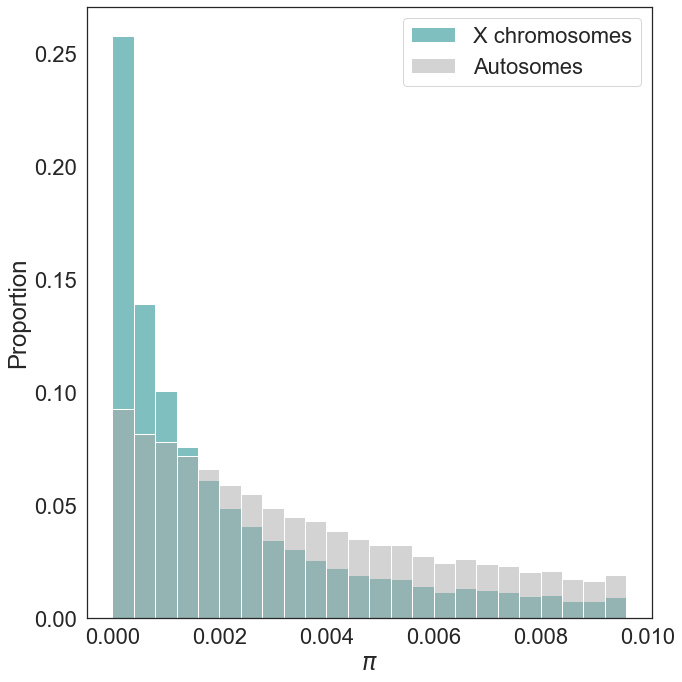

In [39]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(figsize = [10, 10])

ax = axs

bins = np.arange(0, 0.01, 0.0004)

A_df = intergenic_df[~intergenic_df['chrom'].isin(x_list)]
X_df = intergenic_df[intergenic_df['chrom'].isin(x_list)]

sns.histplot(X_df['pi'], label='X chromosomes', bins=bins, alpha = 0.5, stat='proportion', ax = ax, color='teal')
sns.histplot(A_df['pi'], label='Autosomes', bins=bins, alpha = 0.5, stat='proportion', ax = ax, color='darkgrey')

ax.legend()

ax.set_xlabel(r'$\pi$')

#ax.axvline(A_df['pi'].mean(), linestyle='--',color='darkgrey')
#ax.axvline(X_df['pi'].mean(), linestyle='--',color='teal')


plt.tight_layout()

In [40]:
intergenic_df[(intergenic_df['chrom'].isin(x_list)) & (intergenic_df['pi']<0.001)]['chrom'].value_counts()

OX359249.1    9209
OX359250.1    6556
Name: chrom, dtype: int64

<AxesSubplot:xlabel='start', ylabel='Count'>

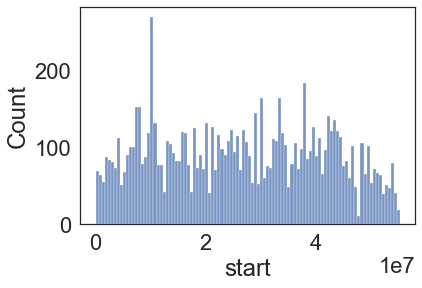

In [41]:
sns.histplot(intergenic_df[(intergenic_df['chrom']=='OX359249.1') & (intergenic_df['pi']<0.001)]['start'], bins=100)

<AxesSubplot:xlabel='start', ylabel='Count'>

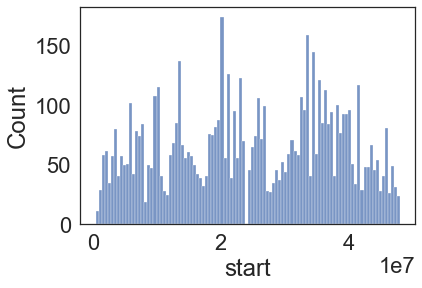

In [42]:
sns.histplot(intergenic_df[(intergenic_df['chrom']=='OX359250.1') & (intergenic_df['pi']<0.001)]['start'], bins=100)

In [43]:
def norm_sfs(sfs):
    sfs = sfs[1:]#sfs.to_numpy(dtype=float)[1:]
    sfs/=np.sum(sfs)
    return sfs

In [369]:
sfs_df = pd.read_csv('allacma_fusca.sfs.chrom.tsv', sep='\t')

In [371]:
x_chrom

NameError: name 'x_chroms' is not defined

In [367]:
A_0_sfs = sfs_df[(sfs_df['linkage']=='A') & (sfs_df['degeneracy']=='0D')].groupby('iton').sum()
X_0_sfs = sfs_df[(sfs_df['linkage']=='X') & (sfs_df['degeneracy']=='0D')].groupby('iton').sum()
A_4_sfs = sfs_df[(sfs_df['linkage']=='A') & (sfs_df['degeneracy']=='4D')].groupby('iton').sum()
X_4_sfs = sfs_df[(sfs_df['linkage']=='X') & (sfs_df['degeneracy']=='4D')].groupby('iton').sum()

#cant estimate diversity without 0 counts?

In [44]:
#a_intergenic_sfs = [79928954, 261442,126149,92873,79713,72318,66312,70651,78156,66132,58349,61860,46108]
#x_intergenic_sfs = [37238756, 19843,13264,7626,6083,5668,5574,4999,6215,4546,5006,5962,8822]

a_norm_sfs = norm_sfs(a_intergenic_sfs)
x_norm_sfs = norm_sfs(x_intergenic_sfs)

nsamp = len(a_norm_sfs)
sfs_exp_un = [1/i for i in range(1,2*nsamp)]
sfs_exp_un /= np.sum(sfs_exp_un)
flipped = np.flip(sfs_exp_un)
sfs_exp = sfs_exp_un + flipped #sum them together for the 'folding'
sfs_exp = sfs_exp[0:nsamp] # only look at the minor allele counts
#sfs_exp[-1] = sfs_exp[-1]/2 # because we've counted the entry for this twice

sfs_df = pd.DataFrame({'degeneracy': ['Neutral expectation']*nsamp+['Autosomes']*nsamp+['Xs']*nsamp,
                         'itons':np.tile(np.arange(1, nsamp+1),3),
                         'sfs': np.concatenate((sfs_exp, a_norm_sfs, x_norm_sfs))
                        })

Text(0.08, 0.5, 'Normalised SFS')

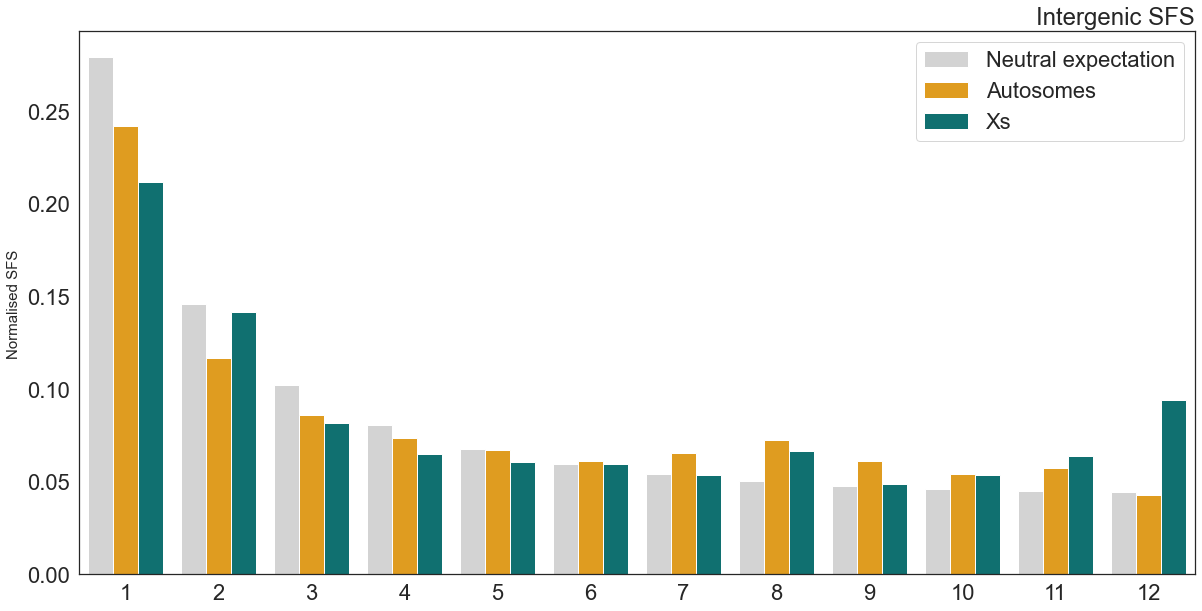

In [45]:
plt.rcParams.update({'font.size':15})
sns.set_palette('muted')

fig, axs = plt.subplots(figsize = [20,10])

ax=axs

sns.barplot(data = sfs_df,
            x='itons', 
            y = 'sfs', 
            hue = 'degeneracy', 
            palette = ['lightgrey','orange','teal'],
            ax = ax)

ax.legend(title=None)
ax.set_title('Intergenic SFS', loc='right')
ax.set_xlabel('')
ax.set_ylabel('')
#a_ax.set_ylim([0,0.35])
#x_ax.set_ylim([0,0.35])

fig.text(0.08, 0.5, 'Normalised SFS', ha='center', va='center', rotation='vertical')

## 1 male sample, so 23 possible haplotypes, i dont think?

In [46]:
import math

def S(sfs):
    return np.sum(sfs[1:])

def maf(sfs):
    return np.sum(sfs * (np.arange(len(sfs))/(2*len(sfs[1:]))))/np.sum(sfs)

def sfs_mean(sfs):
    return np.sum(sfs * np.arange(len(sfs)))/np.sum(sfs) 

def wattersons_theta(sfs, nsamp):

    wattersons_correction = np.sum([1/i for i in range(1,nsamp+1)])
    S = np.sum(sfs[1:])
    #wattersons_theta = S / wattersons_correction
    wattersons_theta = S / (np.sum(sfs) *  wattersons_correction)
    
    return wattersons_theta

def pi(sfs, nsamp):
    
    numerator = sum([count*((i+1)*((2*nsamp)-(i+1))) for i, count in enumerate(sfs[1:])])
    denominator = math.comb(nsamp,2)
    pi_s = numerator/denominator
    pi = pi_s / np.sum(sfs)
    
    return pi

def tajimas_d(pi, theta):
    return pi-theta

In [47]:
print(f'Autosomal theta: {wattersons_theta(a_intergenic_sfs, nsamp):.4f}')
print(f'X theta: {wattersons_theta(x_intergenic_sfs, nsamp):.5f}')
print(f'Autosomal pi: {pi(a_intergenic_sfs, nsamp):.4f}')
print(f'X pi: {pi(x_intergenic_sfs, nsamp):.4f}')

print(f'Autosomal tajimas d: {tajimas_d(pi(a_intergenic_sfs, nsamp), wattersons_theta(a_intergenic_sfs, nsamp)):.4f}')
print(f'X tajimas d: {tajimas_d(pi(x_intergenic_sfs, nsamp), wattersons_theta(x_intergenic_sfs, nsamp)):.4f}')

Autosomal theta: 0.0043
X theta: 0.00081


AttributeError: module 'math' has no attribute 'comb'

In [360]:
0.00081/0.0043

0.1883720930232558

In [48]:
print(0.0032/0.0166)
print(0.0008/0.0043)
# X pi and theta are small compared to autosomes
print(0.0024/0.0123)
# Tajimas D also more positive but relatively they are the same as the diversity values, makes sense
# Likely population subdivision across springtails or bottleneck
# Still dont know why diversity is so much lower on the Xs

0.1927710843373494
0.18604651162790697
0.19512195121951217


In [49]:
pi_dxy_df = dxy_df.merge(pi_sco, how = 'outer',on = 'Orthogroup')
pi_dxy_df = pi_dxy_df.dropna()
pi_dxy_df['gene_pop_alpha'] = 1 - (pi_dxy_df['0/4D_pi']/pi_dxy_df['dnds'])
pi_dxy_df.replace([np.inf, -np.inf], np.nan, inplace=True)
pi_dxy_df.gene_pop_alpha.quantile(0.95)
pi_dxy_df

,Orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,...,gene,chrom_x,pi_gene_x,chrom_y,feature,0D_pi,4D_pi,0/4D_pi,pi_gene_y,gene_pop_alpha
1,OG0014957,0.000829,0.0,0.000415,0.012821,0.0,0.006410,0.018462,0.579609,0.018047,...,g13774.t1,OX359247.1,g13774,OX359247.1,ID=g13774,0.005617,0.004359,1.288760,g13774,-39.461101
2,OG0005328,0.001048,0.0,0.000524,0.001984,0.0,0.000992,0.087896,0.625991,0.087372,...,g692.t1,OX359245.1,g692,OX359245.1,ID=g692,0.003053,0.004188,0.728875,g692,-4.191038
3,OG0014335,0.000000,0.0,0.000000,0.002193,0.0,0.001096,0.019080,0.497999,0.019080,...,g12457.t1,OX359247.1,g12457,OX359247.1,ID=g12457,0.002852,0.001587,1.797120,g12457,-45.907037
5,OG0009570,0.000061,0.0,0.000031,0.000347,0.0,0.000174,0.036087,0.559840,0.036056,...,g6738.t1,OX359246.1,g6738,OX359246.1,ID=g6738,0.000186,0.000103,1.797327,g6738,-26.882982
7,OG0014290,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.051732,0.502096,0.051732,...,g12357.t1,OX359247.1,g12357,OX359247.1,ID=g12357,0.001731,0.003352,0.516362,g12357,-4.011672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12205,OG0012885,0.000277,0.0,0.000138,0.001692,0.0,0.000846,0.032711,0.399048,0.032573,...,g10147.t1,OX359247.1,g10147,OX359247.1,ID=g10147,0.005967,0.002145,2.781600,g10147,-32.933245
12210,OG0008254,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.019283,0.501091,0.019283,...,g19959.t1,OX359249.1,g19959,OX359249.1,ID=g19959,0.001022,0.000237,4.319254,g19959,-111.240121
12211,OG0009699,0.001823,0.0,0.000912,0.027819,0.0,0.013910,0.027340,0.621883,0.026429,...,g7027.t1,OX359246.1,g7027,OX359246.1,ID=g7027,0.013389,0.009887,1.354162,g7027,-29.801724
12219,OG0010183,0.000000,0.0,0.000000,0.026204,0.0,0.013102,0.053974,0.603672,0.053974,...,g8011.t1,OX359246.1,g8011,OX359246.1,ID=g8011,0.005516,0.000493,11.186383,g8011,-124.114463


(array([6.420e+02, 1.095e+03, 5.570e+02, 1.600e+02, 3.400e+01, 1.300e+01,
        6.000e+00, 0.000e+00, 1.000e+00, 2.000e+00]),
 array([0.        , 0.05799476, 0.11598951, 0.17398427, 0.23197903,
        0.28997379, 0.34796854, 0.4059633 , 0.46395806, 0.52195281,
        0.57994757]),
 <BarContainer object of 10 artists>)

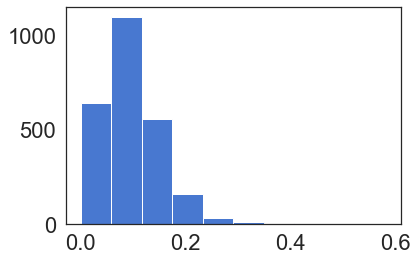

In [50]:
plt.hist(pi_dxy_df[~pi_dxy_df.chrom_x.isin(x_list)]['dnds'])

(array([ 52., 102.,  56.,  46.,   5.,   4.,   1.,   0.,   0.,   1.]),
 array([0.        , 0.04320018, 0.08640037, 0.12960055, 0.17280073,
        0.21600092, 0.2592011 , 0.30240128, 0.34560146, 0.38880165,
        0.43200183]),
 <BarContainer object of 10 artists>)

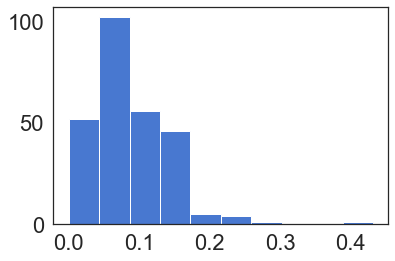

In [51]:
plt.hist(pi_dxy_df[pi_dxy_df.chrom_x.isin(x_list)]['dnds'])

(array([16., 34., 39., 17.,  9.,  3.,  2.,  1.,  0.,  2.]),
 array([0.02314316, 0.0788236 , 0.13450404, 0.19018448, 0.24586493,
        0.30154537, 0.35722581, 0.41290625, 0.46858669, 0.52426713,
        0.57994757]),
 <BarContainer object of 10 artists>)

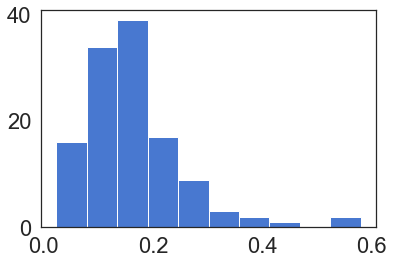

In [52]:
plt.hist(pi_dxy_df[(pi_dxy_df['gene_pop_alpha']>-1.06) & ~(pi_dxy_df.chrom_x.isin(x_list))]['dnds'])

(array([ 6.,  6., 10.,  1.,  1.,  1.,  0.,  0.,  0.,  1.]),
 array([0.04600139, 0.08460143, 0.12320148, 0.16180152, 0.20040157,
        0.23900161, 0.27760165, 0.3162017 , 0.35480174, 0.39340179,
        0.43200183]),
 <BarContainer object of 10 artists>)

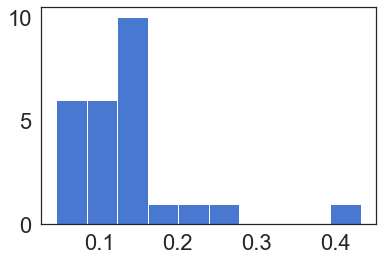

In [53]:
plt.hist(pi_dxy_df[(pi_dxy_df['gene_pop_alpha']>-1.06) & (pi_dxy_df.chrom_x.isin(x_list))]['dnds'])

In [54]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['0d_pi_allacma_fusca']>0) & (dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    148.000000
mean       0.078612
std        0.047381
min        0.010513
25%        0.047107
50%        0.068306
75%        0.092862
max        0.260503
Name: dnds, dtype: float64

In [55]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['0d_pi_allacma_fusca']>0) & (~dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    1622.000000
mean        0.091728
std         0.050129
min         0.002131
25%         0.055113
50%         0.082194
75%         0.118165
max         0.492010
Name: dnds, dtype: float64

In [56]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['alpha']>0) & (dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    523.000000
mean       0.063409
std        0.044482
min        0.000000
25%        0.032169
50%        0.053634
75%        0.087638
max        0.260503
Name: dnds, dtype: float64

In [57]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['alpha']>0) & (~dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    2960.000000
mean        0.074280
std         0.052301
min         0.000000
25%         0.037163
50%         0.063594
75%         0.098446
max         0.579948
Name: dnds, dtype: float64

In [58]:
# maybe i can change it so i use gene_pop pnps if ortholog_pop_gen pnps is not available, not exclusively using one or the other. how could it not be available from gene pop if it is from ortholog pop gen though?

In [59]:
dxy_df

,Orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,gene,chrom,pi_gene
0,OG0009945,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.007130,0.395062,0.007130,0.395062,0.018048,1.000000,g7546.t1,OX359246.1,g7546
1,OG0014957,0.000829,0.0,0.000415,0.012821,0.0,0.006410,0.018462,0.579609,0.018047,0.573199,0.031852,-1.030545,g13774.t1,OX359247.1,g13774
2,OG0005328,0.001048,0.0,0.000524,0.001984,0.0,0.000992,0.087896,0.625991,0.087372,0.624999,0.140410,-2.760860,g692.t1,OX359245.1,g692
3,OG0014335,0.000000,0.0,0.000000,0.002193,0.0,0.001096,0.019080,0.497999,0.019080,0.496902,0.038312,1.000000,g12457.t1,OX359247.1,g12457
4,OG0009687,0.000128,0.0,0.000064,0.000000,0.0,0.000000,0.041688,0.542056,0.041624,0.542056,0.076907,1.000000,g7009.t1,OX359246.1,g7009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12226,OG0011137,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.037713,0.550000,0.037713,0.550000,0.068569,1.000000,g21684.t1,OX359250.1,g21684
12227,OG0012449,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.250000,0.000000,0.250000,0.000000,1.000000,g9490.t2,OX359247.1,g9490
12228,OG0010082,0.000889,0.0,0.000444,0.002727,0.0,0.001364,0.106984,0.551303,0.106540,0.549939,0.194057,-0.679040,g7777.t1,OX359246.1,g7777
12229,OG0014877,0.000000,0.0,0.000000,0.001022,0.0,0.000511,0.004124,0.445444,0.004124,0.444933,0.009258,1.000000,g13609.t1,OX359247.1,g13609


<AxesSubplot:xlabel='0d_dxy', ylabel='4D_pi'>

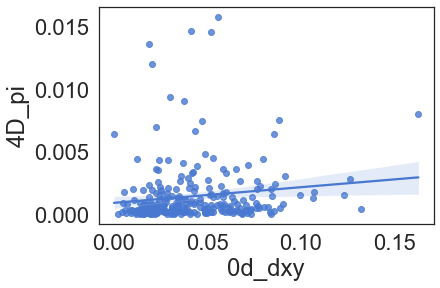

In [60]:
sns.regplot(data = pi_dxy_df[(pi_dxy_df.chrom_x.isin(x_list))],
           x='0d_dxy',
           y = '4D_pi')

Text(0, 0.5, 'Neutral diversity')

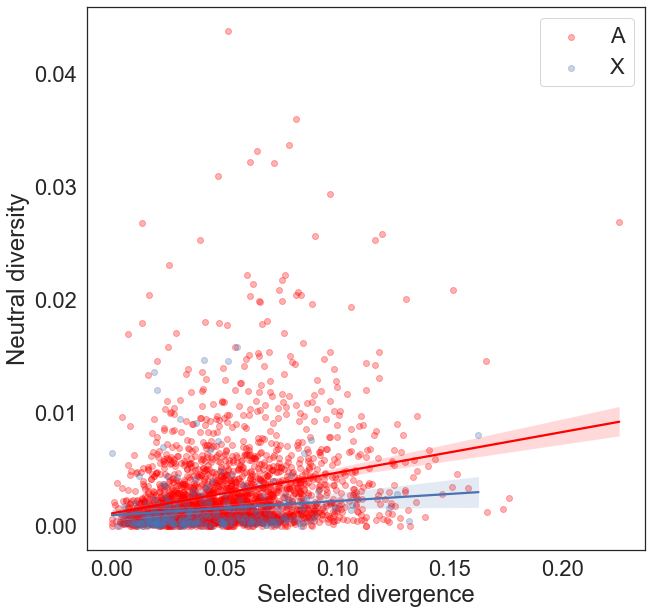

In [61]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(figsize = [10, 10])

axs = sns.regplot(data = pi_dxy_df[~(pi_dxy_df.chrom_x.isin(x_list))],
           x='0d_dxy',
           y = '4D_pi',
           color='red',
           scatter_kws={'alpha':0.3},
           label='A')

axs = sns.regplot(data = pi_dxy_df[(pi_dxy_df.chrom_x.isin(x_list))],
           x='0d_dxy',
           y = '4D_pi',
           scatter_kws={'alpha':0.3},
           label='X')

axs.legend()
axs.set_xlabel('Selected divergence')
axs.set_ylabel('Neutral diversity')

In [62]:
gcf = 'allacma_fusca.gc.bed'
gcdf = pd.read_csv(gcf, sep='\t', names=['chromosome','start','stop','gc'])
gcdf = gcdf[gcdf.chromosome.isin(['OX359245.1','OX359246.1', 'OX359247.1', 'OX359248.1', 'OX359249.1','OX359250.1'])].reset_index(drop=True)
gcdf['midpoint'] = gcdf['start'] + (gcdf['stop'] - gcdf['start'])/2

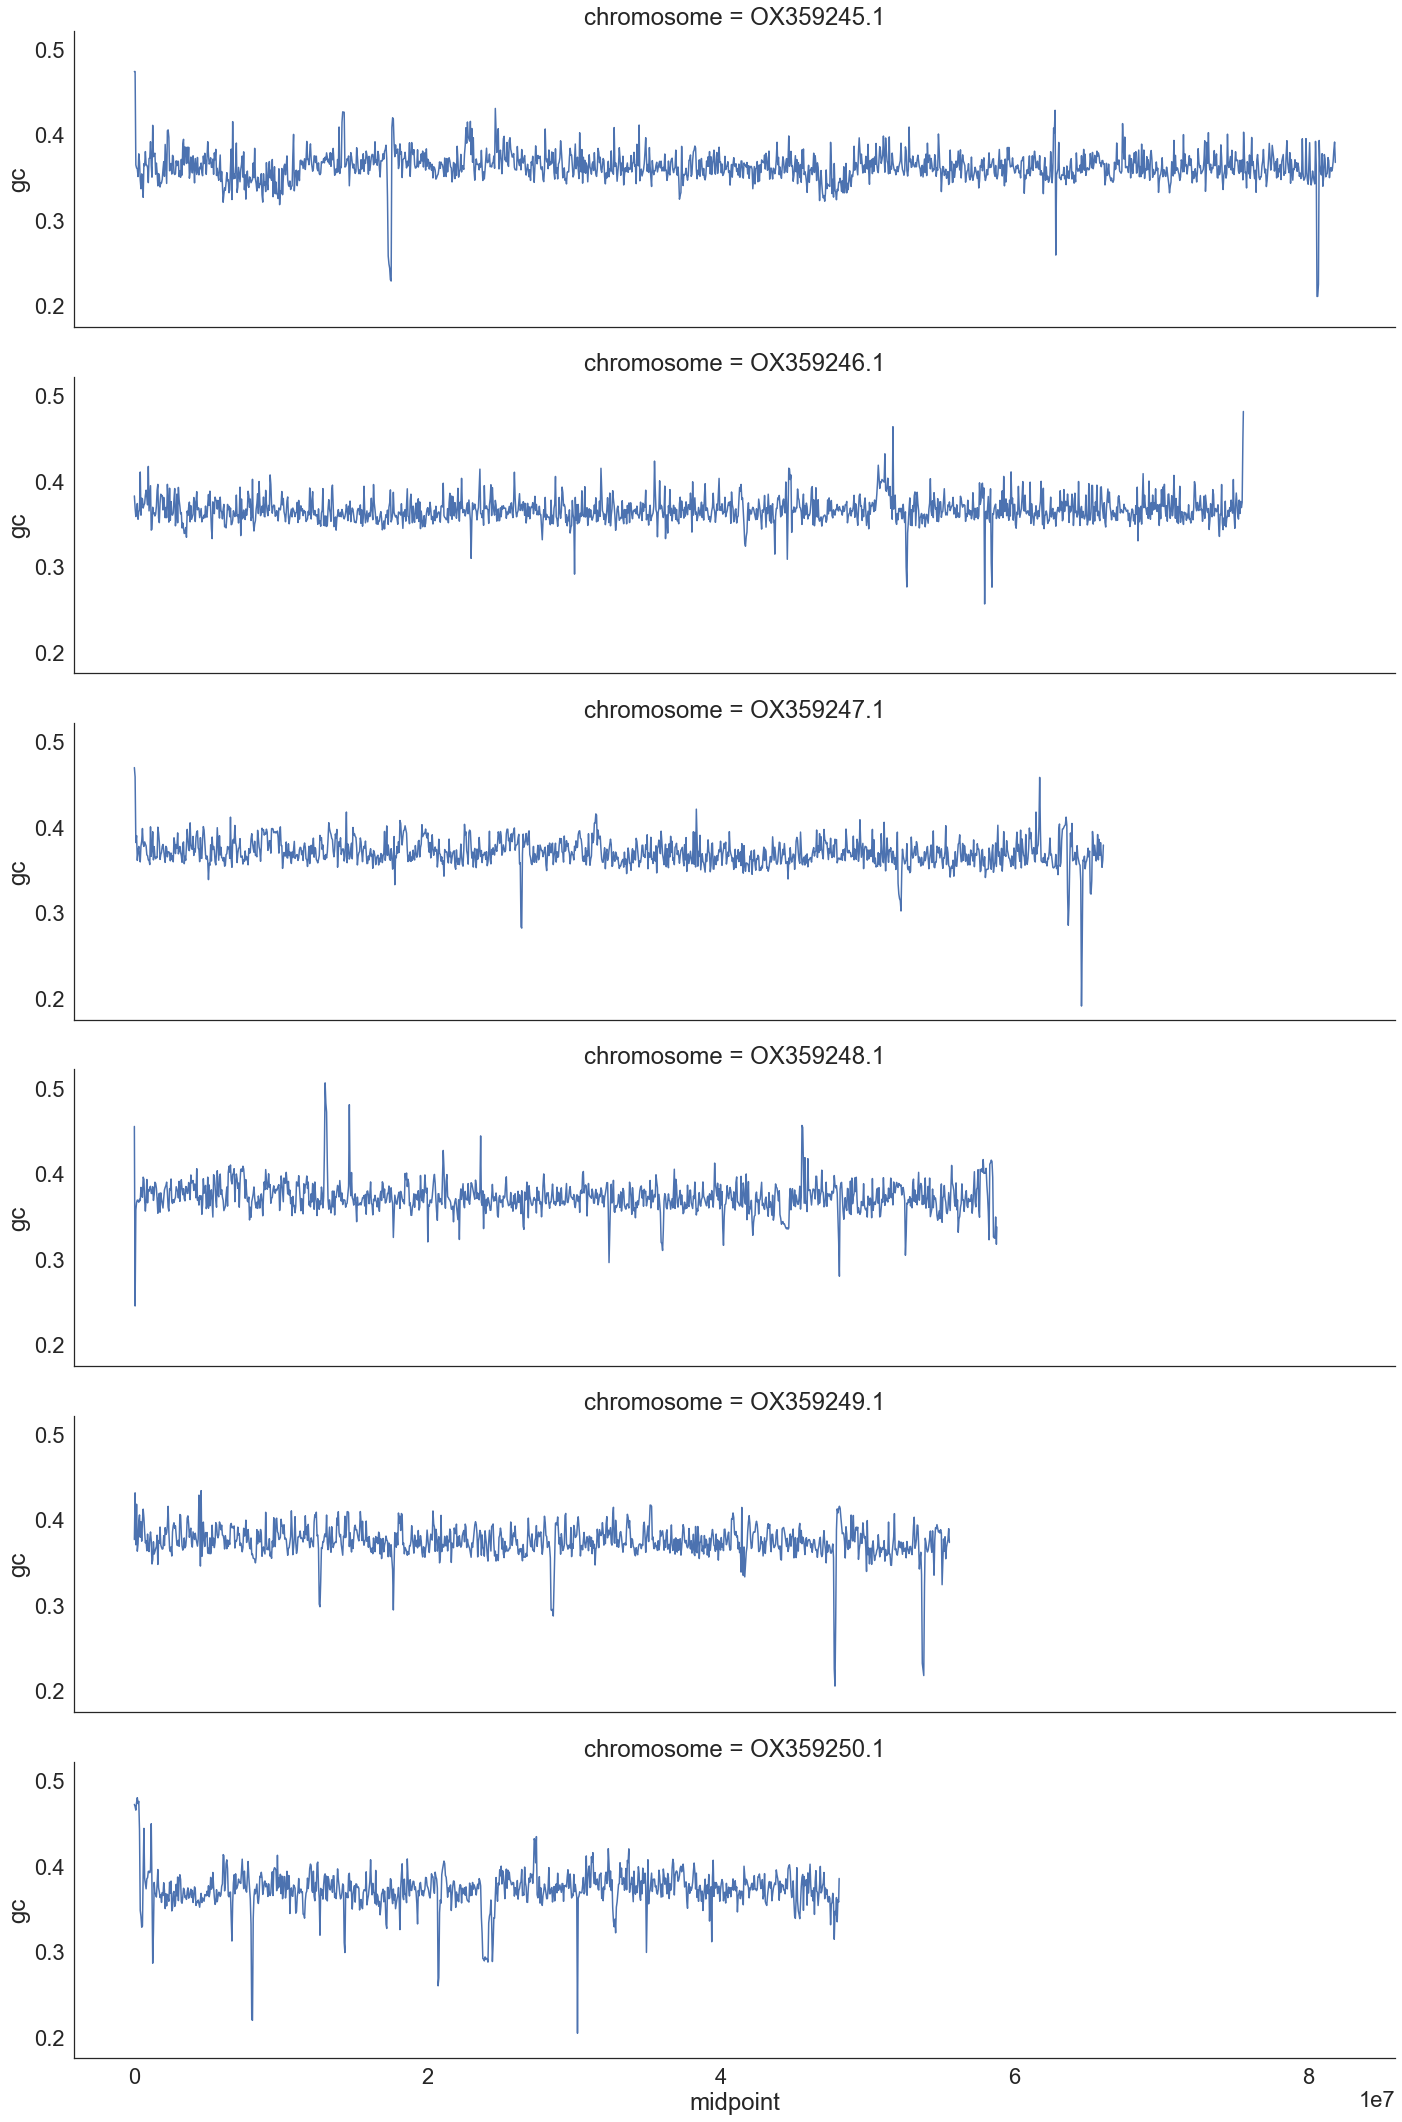

In [63]:
#sns.set(font_scale=2, style='white')

sns.relplot(data = gcdf,
           x = 'midpoint',
           y = 'gc',
           row = 'chromosome',
           kind='line',
           height=5,
           aspect=4
           )

In [64]:
!ls

a_fop.csv
a_intergenic.windowed.pi
Afusca Svir ortholog pop gen.ipynb
all_chrs.intergenic.pi.tsv
allacma_fusca.gc.bed
allacma_fusca.gene.AGAT.bed
allacma_fusca.longest_isoforms.pi.tsv
allacma_fusca.sminthurus_viridis.orthodiver_agg.tsv
allacma_fusca.sp1.SCO_genes.txt
dnds.ipynb
Orthogroups_SingleCopyOrthologues.txt
Orthogroups.tsv
SC_orthogroups.txt
SFS.ipynb
sminthurus_viridis.sp2.SCO_genes.txt
x_fop.csv
x_intergenic.windowed.pi


In [6]:
afop_df = pd.read_csv('a_fop_tmm.csv')
xfop_df = pd.read_csv('x_fop_tmm.csv')

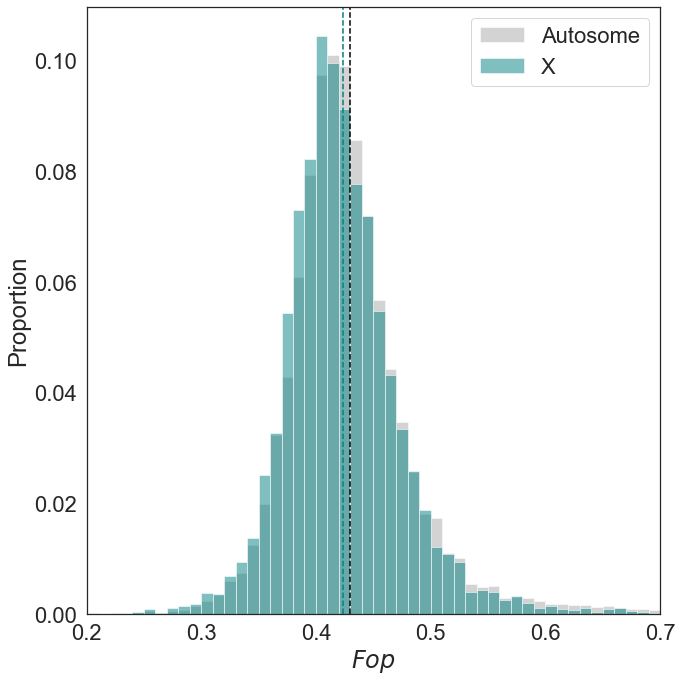

In [8]:
sns.set(font_scale=2, style='white')
fig, axs = plt.subplots(figsize = [10, 10])

ax = axs

bins = np.arange(0, 1, 0.01)

sns.histplot(afop_df['a_fop'], label='Autosome', bins=bins, alpha = 0.5, stat='proportion', ax = ax, color='darkgrey')
sns.histplot(xfop_df['x_fop'], label='X', bins=bins, alpha = 0.5, stat='proportion', ax = ax, color='teal')

ax.legend()

ax.set_xlabel(r'$Fop$')
ax.set_xlim([0.2, 0.7])

ax.axvline(0.4293198, linestyle='--',color='black')
ax.axvline(0.424003, linestyle='--',color='teal')

plt.tight_layout()

plt.savefig("Fop.svg")
plt.savefig("Fop.png")